# Action Plan Scoring Evaluation

This notebook scores the `rerank_comparison_sample_*.json` reports produced by `Plan.ipynb`. For every sample and every rerank mode (`none` = Dense MMR, `bm25`, `crossencoder`, `colbert`) it computes:

- **Retrieval quality**: `Recall@10` and `nDCG@10` using a weak graded-relevance signal (`0.5 * ROUGE-1 + 0.5 * SBERT cosine`). Recall is evaluated over the **wider reranked candidate pool** (default 30 chunks) that `Plan.ipynb` persists under `rag_info.candidate_pool`, so the denominator is larger than *k* and recall can take fractional values.
- **Context grounding** (`RI_SBert` / `CRAG`): SBERT cosine and a **3-valued CRAG-style proxy** (`+1` accurate, `0` partial, `-1` incorrect) between the top-10 retrieved context and a **label-derived reference string** built deterministically from `attack_options.json` (actions per attack label) and `agentic_features.json` (which agents can execute which actions).
- **Context utilization** (`Util_SBert` / `Util_CRAG`): SBERT cosine and CRAG-style proxy between the top-10 retrieved context and the LLM's `overall_reasoning`. Quantifies how much of the retrieved evidence the LLM actually grounds its answer in (faithfulness / answer-vs-context alignment). Reuses the same adaptive CRAG thresholds as the context-grounding metric.
- **LLM reasoning quality** (`LLM_SBert` / `LLM_CRAG` / `BertscoreF1`): SBERT cosine, CRAG proxy, and `BERTScore-F1` between `overall_reasoning` and the same reference string.

Thresholds for the graded-relevance and CRAG metrics are **adaptive**: the scoring loop first collects the full score distribution across the batch, then sets each threshold to a percentile of that distribution clamped to a relaxed floor (see the `*_FLOOR` constants in the helper-functions cell). Thresholds actually used are printed at the start of the scoring loop and persisted in `scoring_results.json` under `adaptive_thresholds_used`.

## Reference text
The reference is generated per sample by `build_reference_text_for_label(predicted_label)` from `attack_options.json` + `agentic_features.json`. It lists, per responder agent (RAN / Edge / Core), the subset of the attack's action options that each agent's `action_capabilities` can execute, plus any unassigned actions. Example (PORTSCAN): `PORTSCAN response: RAN actions: block IP, limit rate, update ACL. Edge actions: block IP, harden ports. Core actions: update ACL, scan threshold. Unassigned actions: tarpit scan.`

## Inline Parameter Annotations (Score)

Use this reference to interpret scoring outputs and tune evaluation behavior safely.

- `RAG_DOCS_DIR` (`RAG_docs/action_plans`): directory scanned for `rerank_comparison_sample_*.json`; wrong scope mixes runs.
- `rerank_mode` fields (`none` = Dense MMR, `bm25`, `crossencoder`, `colbert`): scoring dimensions used for side-by-side retrieval quality comparison.
- `build_reference_text_for_label(label)`: builds the per-sample reference string from `attack_options.json` + `agentic_features.json`. Lists the attack's action options grouped by the agent (RAN / Edge / Core) capable of executing each action. Quality of this string defines the metric ceiling.
- Candidate `overall_reasoning` (LLM output): text being evaluated against the reference for the LLM-quality metrics.
- `sbert_model` (`all-MiniLM-L6-v2`): embedding backbone for SBERT cosine; keep consistent across runs for fair comparisons.
- `RELEVANCE_FLOOR`, `CRAG_SBERT_FLOOR_*`, `CRAG_ROUGE_FLOOR_*`: relaxed minimum thresholds used when the batch-level adaptive thresholds fall below them. Lowering the floors makes the metrics more permissive; raising them makes them stricter.
- `derive_adaptive_thresholds(...)` percentile arguments (`grade_percentile`, `crag_good_percentile`, `crag_weak_percentile`): control where each threshold sits in the empirical distribution; batch-level adaptive thresholds make metrics less sensitive to absolute scale.
- `TOP_K` (default 10): number of top retrieved chunks used for Recall@k / nDCG@k and for building the concatenated `retrieved_context`.
- ROUGE (`rouge1`): recall-oriented lexical overlap; used in both graded relevance and the CRAG proxy.
- BERTScore (`roberta-large`): contextual token-level similarity between reference and `overall_reasoning`; reported as F1.
- Aggregation (`df_results.groupby("method")`): per-mode averages in `avg_scores`; verify equal sample counts per mode before interpreting averages.
- Output artifacts: `RAG_docs/scoring/scoring_results.json` (detailed per-row scores, including `adaptive_thresholds_used`) and the rerank-method averages CSV.
- Normalization/preprocessing: none beyond tokenization inside each metric; keep stable between experiments to preserve comparability.


In [36]:
# Import required libraries
import json
import os
from pathlib import Path
from typing import Dict, List, Tuple, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scoring libraries
from bert_score import score as bert_score
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Download required NLTK data
import nltk

import json
from collections import defaultdict

# --- Load your KB artifacts ---
ATTACK_OPTIONS_PATH = "RAG_docs/attack_options.json"
AGENTS_PATH = "RAG_docs/agentic_features.json"

with open(ATTACK_OPTIONS_PATH, "r", encoding="utf-8") as f:
    attack_options_kb = json.load(f)["attacks"]

with open(AGENTS_PATH, "r", encoding="utf-8") as f:
    agents_kb = json.load(f)["agents"]

# Normalize action strings for matching
def _norm_action(s: str) -> str:
    return " ".join(s.lower().strip().split())

# Build: action -> agents that can execute it (based on action_capabilities)
action_to_agents = defaultdict(list)
for agent_name, agent_info in agents_kb.items():
    for a in agent_info.get("action_capabilities", []):
        action_to_agents[_norm_action(a)].append(agent_name)

# Optional: synonyms so "limit rate" matches "rate limiting", etc.
# Keep synonyms SHORT and close to what your plan generator actually emits.
ACTION_SYNONYMS = {
    "rate limiting": ["limit rate", "rate limit"],
    "traffic scrubbing": ["enable scrubbing", "scrub traffic"],
    "blackhole routing": ["blackhole route", "blackhole"],
    "ip blocking": ["block ip", "ip block"],
    "acl update": ["update acl", "acl change"],
    "syn cookies": ["enable syn cookies", "syn cookie"],
    "connection limiting": ["limit connections", "conn limit"],
    "account lockout": ["lock account", "lockout"],
    "mfa enforce": ["enforce mfa", "require mfa"],
    "credential throttle": ["throttle login", "login throttle"],
    "fail2ban block": ["fail2ban", "ban ip"],
    "waf rules": ["waf rule", "apply waf"],
    "virtual patching": ["virtual patch", "hot patch"],
    "isolate service": ["isolate", "quarantine service"],
    "captcha challenge": ["captcha", "challenge"],
    "reputation filter": ["reputation", "filter reputation"],
    "js challenge": ["js challenge", "javascript challenge"],
    "tarpitting": ["tarpit", "slow scan"],
    "port hardening": ["harden ports", "close ports"],
    "scan threshold": ["threshold scan", "scan threshold"],
    "auto scale": ["autoscale", "scale out"],
    "log only": ["log", "logging"],
    "monitor": ["monitoring", "observe"],
}

def build_reference_text_for_label(label: str) -> str:
    """
    Create a deterministic 'gold' reference string for scoring,
    based on ``attack_options.json`` (actions per attack label) and
    ``agentic_features.json`` (which agents can execute which actions).

    The reference lists, per responder agent (RAN / Edge / Core), the actions
    that agent is capable of executing for the given attack label — plus any
    actions from the attack's option set that no agent can execute (listed as
    unassigned). No agent prose / descriptions are included.
    """
    label = label.strip().upper()
    actions = attack_options_kb.get(label) or attack_options_kb.get("OTHERS", [])
    actions_norm = [_norm_action(a) for a in actions]

    # Assign each action to agents that can execute it (can be multiple).
    agent_to_actions = defaultdict(list)
    unassigned = []
    for a_raw, a in zip(actions, actions_norm):
        capable_agents = action_to_agents.get(a, [])
        if not capable_agents:
            # If you want STRICT no-unassigned, you can drop it or map to "Core" by policy.
            unassigned.append(a_raw)
            continue

        # Add canonical + synonyms into the agent bucket to maximize token overlap.
        expanded = [a_raw]
        expanded += ACTION_SYNONYMS.get(a, [])
        for ag in capable_agents:
            agent_to_actions[ag].extend(expanded)

    # Stable ordering for reproducible scores
    def uniq(seq):
        seen = set()
        out = []
        for x in seq:
            k = _norm_action(x)
            if k not in seen:
                seen.add(k)
                out.append(x)
        return out

    ran = ", ".join(uniq(agent_to_actions.get("RAN", []))) or "none"
    edge = ", ".join(uniq(agent_to_actions.get("Edge", []))) or "none"
    core = ", ".join(uniq(agent_to_actions.get("Core", []))) or "none"

    # One compact canonical string your metrics will compare against
    ref = (
        f"{label} response: "
        f"RAN actions: {ran}. "
        f"Edge actions: {edge}. "
        f"Core actions: {core}."
    )

    if unassigned:
        ref += f" Unassigned actions: {', '.join(unassigned)}."

    return ref

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Initialize SBERT model (load once, reuse)
print("Loading SBERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Libraries imported successfully!")

Loading SBERT model...
Libraries imported successfully!


## Configuration

In [37]:
# Configuration
#
# The old hard-coded ``REFERENCE_TEXT`` (a DDoS-specific string) has been
# replaced by per-sample reference strings generated from the KB via
# ``build_reference_text_for_label(predicted_label)``. This means SSHPATATOR
# samples are scored against an SSHPATATOR reference, PORTSCAN samples
# against a PORTSCAN reference, etc., each listing the attack's action
# options grouped by the responder agent (RAN / Edge / Core) capable of
# executing each action — taken from ``attack_options.json`` +
# ``agentic_features.json``.
RAG_DOCS_DIR = Path("RAG_docs/action_plans")

print(f"Action plans directory: {RAG_DOCS_DIR}")

# Preview per-label references so you can sanity-check the text the metrics
# will see before running the full scoring loop.
print("\nPer-label reference texts (first 200 chars):")
for _lbl in sorted(attack_options_kb.keys()):
    _ref = build_reference_text_for_label(_lbl)
    _preview = _ref[:200] + ("..." if len(_ref) > 200 else "")
    print(f"  [{_lbl}] {_preview}")

Action plans directory: RAG_docs\action_plans

Per-label reference texts (first 200 chars):
  [BENIGN] BENIGN response: RAN actions: log incident, monitor traffic. Edge actions: log incident, monitor traffic. Core actions: log incident, monitor traffic.
  [BOT] BOT response: RAN actions: limit rate, block IP. Edge actions: captcha challenge, captcha, challenge, limit rate, apply WAF, reputation filter, reputation, filter reputation, block IP, js challenge, j...
  [DDOS] DDOS response: RAN actions: limit rate, update ACL, block IP. Edge actions: limit rate, enable scrubbing, update ACL, block IP, scale service. Core actions: limit rate, enable scrubbing, blackhole rou...
  [DOS] DOS response: RAN actions: limit rate, update ACL, block IP. Edge actions: enable syncookies, limit rate, connection limit, update ACL, block IP, enable scrubbing. Core actions: enable syncookies, lim...
  [FTPPATATOR] FTPPATATOR response: RAN actions: block IP, update ACL. Edge actions: lock account, enforce MF

## Helper Functions

Defines the metric primitives used by the scoring loop:

- `calculate_rouge1_score` / `calculate_sbert_cosine` / `calculate_bertscore_scores` — raw text similarity metrics.
- `_graded_relevance(ref, chunk)` — weak supervision score (`0.5 * ROUGE-1 + 0.5 * SBERT cosine`).
- `calculate_recall_at_k(ranked_grades, pool_grades, k, relevance_threshold)` — recall evaluated over the wider reranked `candidate_pool` persisted by `Plan.ipynb`, so the denominator is the number of relevant chunks in that pool (not in the top-k alone).
- `calculate_ndcg_at_k(ranked_grades, k)` — standard nDCG using the precomputed graded relevances for the top-k chunks.
- `calculate_crag_style_truthfulness(...)` — 3-valued proxy (`+1` / `0` / `-1`) with configurable `sbert_good` / `rouge_good` / `sbert_weak` / `rouge_weak` thresholds.
- `derive_adaptive_thresholds(...)` — computes batch-level percentiles for the relevance threshold and the two CRAG levels, each clamped to a relaxed floor.
- `_get_mode_top_results` / `_get_mode_candidate_pool` — pull the top-10 list and the wider 30-chunk pool out of a rerank comparison report (the pool falls back to the top-10 for reports produced by older `Plan.ipynb` runs).

In [38]:
TOP_K = 10


def extract_overall_reasoning(action_plan: Dict[str, Any]) -> str:
    """Extract overall_reasoning from an action plan."""
    if not isinstance(action_plan, dict):
        return ""
    overall_reasoning = action_plan.get("overall_reasoning", "").strip()
    return overall_reasoning if overall_reasoning else ""


def load_rerank_comparison_files(directory: Path) -> List[Dict[str, Any]]:
    """Load rerank ablation JSON files from the directory."""
    comparison_files = sorted(directory.glob("rerank_comparison_sample_*.json"))
    print(f"Found {len(comparison_files)} rerank comparison file(s)")

    loaded_data = []
    for file_path in comparison_files:
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            if data.get("report_type") != "rerank_ablation_comparison":
                continue
            data["file_path"] = str(file_path)
            data["file_name"] = file_path.name
            loaded_data.append(data)
            print(f"  - Loaded: {file_path.name}")
        except Exception as e:
            print(f"  - Error loading {file_path.name}: {e}")

    return loaded_data


def calculate_bleu_score(reference: str, candidate: str) -> float:
    """Calculate BLEU score between reference and candidate texts."""
    # Tokenize
    ref_tokens = reference.lower().split()
    cand_tokens = candidate.lower().split()
    
    # Use smoothing function to handle cases where n-grams don't match
    smoothing = SmoothingFunction().method1
    score = sentence_bleu([ref_tokens], cand_tokens, smoothing_function=smoothing)
    return score


def calculate_rouge1_score(reference: str, candidate: str) -> float:
    """Calculate ROUGE-1 score only."""
    scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)
    scores = scorer.score(reference, candidate)
    return scores['rouge1'].fmeasure


def calculate_sbert_cosine(reference: str, candidate: str) -> float:
    """Calculate SBERT cosine similarity between reference and candidate texts."""
    # Get embeddings
    ref_embedding = sbert_model.encode([reference])
    cand_embedding = sbert_model.encode([candidate])
    
    # Calculate cosine similarity
    cosine_sim = cosine_similarity(ref_embedding, cand_embedding)[0][0]
    return float(cosine_sim)


def calculate_bertscore_scores(references: List[str], candidates: List[str]) -> Dict[str, float]:
    """Calculate BERTScore (precision, recall, F1) for multiple reference-candidate pairs."""
    # BERTScore expects lists of strings
    P, R, F1 = bert_score(candidates, references, lang='en', verbose=False)
    
    return {
        'bertscore_precision': P.mean().item(),
        'bertscore_recall': R.mean().item(),
        'bertscore_f1': F1.mean().item()
    }

def _chunk_string(result: Dict[str, Any]) -> str:
    title = str(result.get("title", "") or "")
    text = str(result.get("text", "") or "")
    return f"{title}\n\n{text}".strip()


# Fallback (FLOOR) thresholds used when adaptive thresholds are unavailable
# or fall below these values. They are deliberately relaxed vs. the original
# fixed values so that short, templated reference texts don't force every
# long KB chunk to score as "irrelevant" / "incorrect".
RELEVANCE_FLOOR = 0.15            # graded relevance (0.5*ROUGE-1 + 0.5*SBERT)
CRAG_SBERT_FLOOR_GOOD = 0.40
CRAG_ROUGE_FLOOR_GOOD = 0.08
CRAG_SBERT_FLOOR_WEAK = 0.30
CRAG_ROUGE_FLOOR_WEAK = 0.05


def _get_mode_top_results(comp_data: Dict[str, Any], mode_key: str) -> List[Dict[str, Any]]:
    modes = comp_data.get("modes", {}) or {}
    mode_block = modes.get(mode_key, {}) if isinstance(modes, dict) else {}
    rag_info = mode_block.get("rag_info", {}) if isinstance(mode_block, dict) else {}
    top_results = rag_info.get("top_results", []) if isinstance(rag_info, dict) else []
    return top_results if isinstance(top_results, list) else []


def _get_mode_candidate_pool(comp_data: Dict[str, Any], mode_key: str) -> List[Dict[str, Any]]:
    """Return the wider candidate pool persisted by Plan.ipynb (if present).

    Falls back to ``top_results`` when the report was produced by an older Plan
    run that only persisted the top-10. Recall@k remains meaningful as long as
    the pool is larger than ``k``.
    """
    modes = comp_data.get("modes", {}) or {}
    mode_block = modes.get(mode_key, {}) if isinstance(modes, dict) else {}
    rag_info = mode_block.get("rag_info", {}) if isinstance(mode_block, dict) else {}
    pool = rag_info.get("candidate_pool") if isinstance(rag_info, dict) else None
    if isinstance(pool, list) and pool:
        return pool
    return _get_mode_top_results(comp_data, mode_key)


def _graded_relevance(reference_text: str, chunk_text: str) -> float:
    if not chunk_text.strip():
        return 0.0
    rouge = calculate_rouge1_score(reference_text, chunk_text)
    sem = calculate_sbert_cosine(reference_text, chunk_text)
    return float(max(0.0, 0.5 * rouge + 0.5 * sem))


def calculate_recall_at_k(
    ranked_grades: List[float],
    pool_grades: List[float],
    k: int = 10,
    relevance_threshold: float = RELEVANCE_FLOOR,
) -> float:
    """Recall@k over a wider candidate pool.

    ``ranked_grades`` are graded-relevance scores for the top-k retrieved chunks
    (in rank order). ``pool_grades`` are scores for a superset — e.g. the full
    reranked pool of ~30 candidates persisted by Plan.ipynb. When the pool is
    strictly larger than k, recall becomes fractional rather than binary.
    """
    if not pool_grades:
        return 0.0
    total_relevant = sum(1 for g in pool_grades if g >= relevance_threshold)
    if total_relevant == 0:
        return 0.0
    retrieved_relevant = sum(1 for g in ranked_grades[:k] if g >= relevance_threshold)
    return float(min(1.0, retrieved_relevant / total_relevant))


def calculate_ndcg_at_k(ranked_grades: List[float], k: int = 10) -> float:
    """nDCG@k using precomputed graded relevance scores for the top-k chunks."""
    if not ranked_grades:
        return 0.0
    k = min(k, len(ranked_grades))

    dcg = 0.0
    for i, rel in enumerate(ranked_grades[:k], start=1):
        dcg += (2.0**rel - 1.0) / np.log2(i + 1.0)

    ideal = sorted(ranked_grades, reverse=True)[:k]
    idcg = 0.0
    for i, rel in enumerate(ideal, start=1):
        idcg += (2.0**rel - 1.0) / np.log2(i + 1.0)

    return float(dcg / idcg) if idcg > 0 else 0.0


def calculate_crag_style_truthfulness(
    context_sbert: float,
    context_rouge1: float,
    has_answer: bool,
    *,
    sbert_good: float = CRAG_SBERT_FLOOR_GOOD,
    rouge_good: float = CRAG_ROUGE_FLOOR_GOOD,
    sbert_weak: float = CRAG_SBERT_FLOOR_WEAK,
    rouge_weak: float = CRAG_ROUGE_FLOOR_WEAK,
) -> float:
    """CRAG-style 3-valued truthfulness proxy with adaptive thresholds.

    - ``+1`` (accurate): context clears the ``good`` floor on SBERT *or* ROUGE-1.
    - ``0``  (missing / partial): context is present but between the weak and
      good floors — i.e. topically adjacent but not a strong match.
    - ``-1`` (incorrect): context is below both weak floors.

    When Score.ipynb supplies per-batch adaptive thresholds (median / 25th
    percentile) via the keyword arguments, the metric tracks the empirical
    distribution instead of hard-coded cutoffs.
    """
    if not has_answer:
        return 0.0
    if context_sbert >= sbert_good or context_rouge1 >= rouge_good:
        return 1.0
    if context_sbert >= sbert_weak or context_rouge1 >= rouge_weak:
        return 0.0
    return -1.0


def derive_adaptive_thresholds(
    per_chunk_grades: List[float],
    context_sbert_values: List[float],
    context_rouge_values: List[float],
    *,
    grade_percentile: float = 60.0,
    crag_good_percentile: float = 50.0,
    crag_weak_percentile: float = 25.0,
) -> Dict[str, float]:
    """Derive batch-level thresholds from observed score distributions.

    Each threshold is clamped to the configured FLOOR so noisy batches with
    few truly-relevant chunks still yield sensible binary decisions.
    """

    def _pct(xs: List[float], p: float) -> float:
        if not xs:
            return 0.0
        return float(np.percentile(np.asarray(xs, dtype=float), p))

    return {
        "relevance_threshold": max(RELEVANCE_FLOOR, _pct(per_chunk_grades, grade_percentile)),
        "crag_sbert_good": max(CRAG_SBERT_FLOOR_GOOD, _pct(context_sbert_values, crag_good_percentile)),
        "crag_rouge_good": max(CRAG_ROUGE_FLOOR_GOOD, _pct(context_rouge_values, crag_good_percentile)),
        "crag_sbert_weak": max(CRAG_SBERT_FLOOR_WEAK, _pct(context_sbert_values, crag_weak_percentile)),
        "crag_rouge_weak": max(CRAG_ROUGE_FLOOR_WEAK, _pct(context_rouge_values, crag_weak_percentile)),
    }


print("Helper functions defined!")

Helper functions defined!


## Load Comparison Files

In [39]:
# Load all rerank comparison files
comparison_data = load_rerank_comparison_files(RAG_DOCS_DIR)

if not comparison_data:
    print("No rerank comparison files found!")
else:
    print(f"\nTotal rerank comparison files loaded: {len(comparison_data)}")

Found 9 rerank comparison file(s)
  - Loaded: rerank_comparison_sample_0_20260421_141522_302176.json
  - Loaded: rerank_comparison_sample_1_20260421_141634_877903.json
  - Loaded: rerank_comparison_sample_2_20260421_141726_355602.json
  - Loaded: rerank_comparison_sample_3_20260421_141823_165782.json
  - Loaded: rerank_comparison_sample_4_20260421_141924_569501.json
  - Loaded: rerank_comparison_sample_5_20260421_142017_669057.json
  - Loaded: rerank_comparison_sample_6_20260421_142107_264057.json
  - Loaded: rerank_comparison_sample_7_20260421_142200_538387.json
  - Loaded: rerank_comparison_sample_8_20260421_142302_261760.json

Total rerank comparison files loaded: 9


## Extract Overall Reasoning and Calculate Scores

Two-pass scoring so thresholds track the actual score distribution rather than arbitrary fixed cutoffs.

**Pass 1** — for every `(sample, mode)` pair:
- Grade every chunk in the mode's `candidate_pool` (the wider 30-chunk reranked pool) against the per-sample reference text.
- Record the graded scores, the top-10 ranked grades, and the context-level SBERT / ROUGE-1 against the concatenated retrieved context.

After pass 1, `derive_adaptive_thresholds` computes:
- `relevance_threshold` — 60th percentile of all graded-relevance scores, floored at `RELEVANCE_FLOOR` (0.15). Used for Recall@10.
- `crag_sbert_good` / `crag_rouge_good` — medians of context SBERT / ROUGE, floored at `CRAG_SBERT_FLOOR_GOOD` (0.40) / `CRAG_ROUGE_FLOOR_GOOD` (0.08). Used for the CRAG `+1` decision.
- `crag_sbert_weak` / `crag_rouge_weak` — 25th percentiles, floored at the `*_WEAK` constants (0.30 / 0.05). Used for the CRAG `0` vs `-1` decision.

**Pass 2** — uses those thresholds to emit `Recall@10`, `nDCG@10`, context / reasoning SBERT cosine, 3-valued CRAG proxies, and `BERTScore-F1`. Each row also carries `pool_size` and `relevance_threshold_used` for traceability.

In [40]:
# Score rerank modes with retrieval + reasoning metrics.
#
# Two-pass pipeline so thresholds for Recall@k and CRAG track the actual score
# distribution rather than arbitrary fixed cutoffs:
#   Pass 1: grade every chunk in each mode's candidate_pool (and compute
#           context SBERT / ROUGE-1) for every (sample, mode). Collect the
#           scores so we can derive adaptive thresholds.
#   Pass 2: emit Recall@10 (over the wider pool), nDCG@10, CRAG-style
#           truthfulness, BERTScore, etc., using the adaptive thresholds.

RERANK_MODES = ["none", "bm25", "crossencoder", "colbert"]

pass1_rows: List[Dict[str, Any]] = []
all_pool_grades: List[float] = []
all_context_sberts: List[float] = []
all_context_rouges: List[float] = []

for comp_data in comparison_data:
    file_name = comp_data["file_name"]
    sample_id = comp_data.get("sample_id", "unknown")
    predicted_label = comp_data.get("prediction", {}).get("predicted_label", "OTHERS")
    reference_text = build_reference_text_for_label(predicted_label)

    modes = comp_data.get("modes", {}) or {}
    if not isinstance(modes, dict):
        continue

    for mode_key in RERANK_MODES:
        mode_block = modes.get(mode_key, {}) if isinstance(modes, dict) else {}
        if not isinstance(mode_block, dict):
            continue

        plan = mode_block.get("llm_action_plan", {})
        overall_reasoning = extract_overall_reasoning(plan)

        top_results = _get_mode_top_results(comp_data, mode_key)
        ranked_chunk_texts = [_chunk_string(r) for r in top_results]
        retrieved_context = "\n\n".join(ranked_chunk_texts[:TOP_K]).strip()

        # Wider pool for Recall@k denominator — falls back to top_results
        # when the report came from an older Plan.ipynb run.
        candidate_pool = _get_mode_candidate_pool(comp_data, mode_key)
        pool_chunk_texts = [_chunk_string(r) for r in candidate_pool]

        ranked_grades = [_graded_relevance(reference_text, t) for t in ranked_chunk_texts]
        # Re-use ranked grades for the prefix of the pool (cost saver) and
        # grade any additional pool chunks beyond top_k.
        pool_grades = list(ranked_grades)
        for t in pool_chunk_texts[len(ranked_grades):]:
            pool_grades.append(_graded_relevance(reference_text, t))

        context_sbert = (
            calculate_sbert_cosine(reference_text, retrieved_context)
            if retrieved_context else 0.0
        )
        context_rouge1 = (
            calculate_rouge1_score(reference_text, retrieved_context)
            if retrieved_context else 0.0
        )

        # Context utilization / faithfulness: how much of the retrieved context is
        # reflected in the LLM's overall_reasoning. Mirrors the (reference vs context)
        # pair but replaces "reference" with the retrieved context itself, so a high
        # score means the LLM actually grounded its answer in what was retrieved.
        utilization_sbert = (
            calculate_sbert_cosine(retrieved_context, overall_reasoning)
            if retrieved_context and overall_reasoning else 0.0
        )
        utilization_rouge1 = (
            calculate_rouge1_score(retrieved_context, overall_reasoning)
            if retrieved_context and overall_reasoning else 0.0
        )

        all_pool_grades.extend(pool_grades)
        if retrieved_context:
            all_context_sberts.append(context_sbert)
            all_context_rouges.append(context_rouge1)

        pass1_rows.append({
            "file_name": file_name,
            "sample_id": sample_id,
            "predicted_label": predicted_label,
            "method": mode_key,
            "reference_text": reference_text,
            "overall_reasoning": overall_reasoning,
            "retrieved_context": retrieved_context,
            "ranked_grades": ranked_grades,
            "pool_grades": pool_grades,
            "pool_size": len(pool_grades),
            "context_sbert": context_sbert,
            "context_rouge1": context_rouge1,
            "utilization_sbert": utilization_sbert,
            "utilization_rouge1": utilization_rouge1,
        })

adaptive = derive_adaptive_thresholds(
    per_chunk_grades=all_pool_grades,
    context_sbert_values=all_context_sberts,
    context_rouge_values=all_context_rouges,
)

print("Adaptive thresholds (batch-derived, clamped to floors):")
for k, v in adaptive.items():
    print(f"  {k:>22s} = {v:.4f}")

scoring_results: List[Dict[str, Any]] = []
current_file = None

for row in pass1_rows:
    file_name = row["file_name"]
    sample_id = row["sample_id"]
    predicted_label = row["predicted_label"]
    mode_key = row["method"]
    reference_text = row["reference_text"]
    overall_reasoning = row["overall_reasoning"]
    retrieved_context = row["retrieved_context"]
    ranked_grades = row["ranked_grades"]
    pool_grades = row["pool_grades"]
    context_sbert = row["context_sbert"]
    context_rouge1 = row["context_rouge1"]
    utilization_sbert = row["utilization_sbert"]
    utilization_rouge1 = row["utilization_rouge1"]

    if file_name != current_file:
        current_file = file_name
        print(f"\n{'='*60}")
        print(f"File: {file_name} (Sample ID: {sample_id}, Label: {predicted_label})")
        print(f"{'='*60}")

    recall_at_10 = calculate_recall_at_k(
        ranked_grades=ranked_grades,
        pool_grades=pool_grades,
        k=TOP_K,
        relevance_threshold=adaptive["relevance_threshold"],
    )
    ndcg_at_10 = calculate_ndcg_at_k(ranked_grades=ranked_grades, k=TOP_K)

    reasoning_sbert = (
        calculate_sbert_cosine(reference_text, overall_reasoning)
        if overall_reasoning else 0.0
    )
    reasoning_rouge1 = (
        calculate_rouge1_score(reference_text, overall_reasoning)
        if overall_reasoning else 0.0
    )

    bertscore_reasoning = (
        calculate_bertscore_scores([reference_text], [overall_reasoning])
        if overall_reasoning
        else {"bertscore_precision": 0.0, "bertscore_recall": 0.0, "bertscore_f1": 0.0}
    )

    crag_context_proxy = calculate_crag_style_truthfulness(
        context_sbert=context_sbert,
        context_rouge1=context_rouge1,
        has_answer=bool(retrieved_context),
        sbert_good=adaptive["crag_sbert_good"],
        rouge_good=adaptive["crag_rouge_good"],
        sbert_weak=adaptive["crag_sbert_weak"],
        rouge_weak=adaptive["crag_rouge_weak"],
    )
    crag_reasoning_proxy = calculate_crag_style_truthfulness(
        context_sbert=reasoning_sbert,
        context_rouge1=reasoning_rouge1,
        has_answer=bool(overall_reasoning),
        sbert_good=adaptive["crag_sbert_good"],
        rouge_good=adaptive["crag_rouge_good"],
        sbert_weak=adaptive["crag_sbert_weak"],
        rouge_weak=adaptive["crag_rouge_weak"],
    )
    # Context utilization CRAG: treats the retrieved context as the "reference"
    # and asks whether the LLM's overall_reasoning accurately reflects it.
    crag_utilization_proxy = calculate_crag_style_truthfulness(
        context_sbert=utilization_sbert,
        context_rouge1=utilization_rouge1,
        has_answer=bool(retrieved_context and overall_reasoning),
        sbert_good=adaptive["crag_sbert_good"],
        rouge_good=adaptive["crag_rouge_good"],
        sbert_weak=adaptive["crag_sbert_weak"],
        rouge_weak=adaptive["crag_rouge_weak"],
    )

    print(
        f"Mode={mode_key:12s} | Recall@10={recall_at_10:.4f} | nDCG@10={ndcg_at_10:.4f} | "
        f"Ctx-SBERT={context_sbert:.4f} | Ctx-CRAG={crag_context_proxy:+.0f} | "
        f"Util-SBERT={utilization_sbert:.4f} | Util-CRAG={crag_utilization_proxy:+.0f} | "
        f"Reason-SBERT={reasoning_sbert:.4f} | BERT-F1={bertscore_reasoning['bertscore_f1']:.4f}"
    )

    scoring_results.append({
        "file_name": file_name,
        "sample_id": sample_id,
        "predicted_label": predicted_label,
        "method": mode_key,
        "text": overall_reasoning,
        "reference_text": reference_text,
        "pool_size": row["pool_size"],
        "recall_at_10": recall_at_10,
        "ndcg_at_10": ndcg_at_10,
        "context_sbert_cosine": context_sbert,
        "context_rouge1": context_rouge1,
        "context_crag_proxy": crag_context_proxy,
        "utilization_sbert_cosine": utilization_sbert,
        "utilization_rouge1": utilization_rouge1,
        "utilization_crag_proxy": crag_utilization_proxy,
        "reasoning_sbert_cosine": reasoning_sbert,
        "reasoning_rouge1": reasoning_rouge1,
        "reasoning_crag_proxy": crag_reasoning_proxy,
        "bertscore_precision": bertscore_reasoning["bertscore_precision"],
        "bertscore_recall": bertscore_reasoning["bertscore_recall"],
        "bertscore_f1": bertscore_reasoning["bertscore_f1"],
        "relevance_threshold_used": adaptive["relevance_threshold"],
    })

print(f"\n\nTotal scoring rows (files x modes): {len(scoring_results)}")

Adaptive thresholds (batch-derived, clamped to floors):
     relevance_threshold = 0.1836
         crag_sbert_good = 0.4000
         crag_rouge_good = 0.0800
         crag_sbert_weak = 0.3000
         crag_rouge_weak = 0.0500

File: rerank_comparison_sample_0_20260421_141522_302176.json (Sample ID: 0, Label: BENIGN)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Mode=none         | Recall@10=0.5294 | nDCG@10=0.9870 | Ctx-SBERT=0.4702 | Ctx-CRAG=+1 | Util-SBERT=0.4443 | Util-CRAG=+1 | Reason-SBERT=0.5256 | BERT-F1=0.8552


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Mode=bm25         | Recall@10=0.4706 | nDCG@10=0.9444 | Ctx-SBERT=0.3566 | Ctx-CRAG=+0 | Util-SBERT=0.2945 | Util-CRAG=-1 | Reason-SBERT=0.5569 | BERT-F1=0.8579


...

Mode=bm25         | Recall@10=0.4615 | nDCG@10=0.9089 | Ctx-SBERT=0.2953 | Ctx-CRAG=-1 | Util-SBERT=0.4452 | Util-CRAG=+1 | Reason-SBERT=0.5654 | BERT-F1=0.8234


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Mode=crossencoder | Recall@10=0.2308 | nDCG@10=0.9121 | Ctx-SBERT=0.2270 | Ctx-CRAG=-1 | Util-SBERT=0.3206 | Util-CRAG=+0 | Reason-SBERT=0.4662 | BERT-F1=0.8200


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Mode=colbert      | Recall@10=0.4000 | nDCG@10=0.9318 | Ctx-SBERT=0.3397 | Ctx-CRAG=+0 | Util-SBERT=0.3925 | Util-CRAG=+0 | Reason-SBERT=0.5650 | BERT-F1=0.8444


Total scoring rows (files x modes): 36


## Create Results DataFrame

Per-row display of the scoring loop output. The underlying DataFrame keeps verbose metric names (`recall_at_10`, `context_sbert_cosine`, `utilization_sbert_cosine`, ...) but the printed table uses the abbreviated labels (`recall@10`, `RI_SBert`, `CRAG`, `Util_SBert`, `Util_CRAG`, `LLM_SBert`, `LLM_CRAG`, `BertscoreF1`). `Util_*` compare retrieved top-10 context against `overall_reasoning` (context utilization / faithfulness). File names are shortened to drop the `rerank_comparison_sample_` prefix.

In [41]:
# Create DataFrame for easier analysis
df_results = pd.DataFrame(scoring_results)

# Short column labels used for display-only (underlying df_results keeps verbose names)
METRIC_DISPLAY_RENAME = {
    "recall_at_10": "recall@10",
    "ndcg_at_10": "ndcg@10",
    "context_sbert_cosine": "RI_SBert",
    "context_crag_proxy": "CRAG",
    "utilization_sbert_cosine": "Util_SBert",
    "utilization_crag_proxy": "Util_CRAG",
    "reasoning_sbert_cosine": "LLM_SBert",
    "reasoning_crag_proxy": "LLM_CRAG",
    "bertscore_f1": "BertscoreF1",
}

def _short_file_name(name: str) -> str:
    # Drop the fixed 'rerank_comparison_sample_' prefix so only <sid>_<timestamp>.json remains
    prefix = "rerank_comparison_sample_"
    return name[len(prefix):] if isinstance(name, str) and name.startswith(prefix) else name

if not df_results.empty:
    print("Scoring Results DataFrame:")
    display_cols = [
        "file_name",
        "sample_id",
        "method",
        "recall_at_10",
        "ndcg_at_10",
        "context_sbert_cosine",
        "context_crag_proxy",
        "utilization_sbert_cosine",
        "utilization_crag_proxy",
        "reasoning_sbert_cosine",
        "reasoning_crag_proxy",
        "bertscore_f1",
    ]
    df_display = df_results[display_cols].copy()
    df_display["file_name"] = df_display["file_name"].map(_short_file_name)
    df_display = df_display.rename(columns=METRIC_DISPLAY_RENAME)
    print(df_display.to_string(index=False))
else:
    print("No results to display!")

Scoring Results DataFrame:
                    file_name  sample_id       method  recall@10  ndcg@10  RI_SBert  CRAG  Util_SBert  Util_CRAG  LLM_SBert  LLM_CRAG  BertscoreF1
0_20260421_141522_302176.json          0         none   0.529412 0.987001  0.470228   1.0    0.444270        1.0   0.525575       1.0     0.855154
0_20260421_141522_302176.json          0         bm25   0.470588 0.944363  0.356567   0.0    0.294512       -1.0   0.556861       1.0     0.857915
0_20260421_141522_302176.json          0 crossencoder   0.250000 0.956339  0.377630   0.0    0.391240        0.0   0.656705       1.0     0.860688
0_20260421_141522_302176.json          0      colbert   0.230769 0.959379  0.470228   1.0    0.449996        1.0   0.583363       1.0     0.862173
1_20260421_141634_877903.json          1         none   0.444444 0.960149  0.339990   0.0    0.414073        1.0   0.548225       1.0     0.820166
1_20260421_141634_877903.json          1         bm25   0.250000 0.919569  0.236771  -1.0  

## Calculate Average Scores

Aggregates the 9 headline metrics (`recall@10`, `ndcg@10`, `RI_SBert`, `CRAG`, `Util_SBert`, `Util_CRAG`, `LLM_SBert`, `LLM_CRAG`, `BertscoreF1`) by rerank mode and overall. `Util_SBert` / `Util_CRAG` quantify how much of the retrieved top-10 context is actually reflected in the LLM's `overall_reasoning` (a faithfulness / context-utilization proxy). `context_rouge1`, `utilization_rouge1`, `reasoning_rouge1`, `bertscore_precision`, and `bertscore_recall` are still present in `scoring_results` but omitted from the averages table to keep the per-mode comparison focused on the primary metrics.

In [42]:
# Calculate average scores by rerank mode
if not df_results.empty:
    metric_cols = [
        "recall_at_10",
        "ndcg_at_10",
        "context_sbert_cosine",
        "context_crag_proxy",
        "utilization_sbert_cosine",
        "utilization_crag_proxy",
        "reasoning_sbert_cosine",
        "reasoning_crag_proxy",
        "bertscore_f1",
    ]

    avg_scores = (
        df_results.groupby("method")[metric_cols]
        .mean()
        .round(4)
        .rename(columns=METRIC_DISPLAY_RENAME)
    )

    print("\nAverage Scores by Rerank Mode:")
    print("=" * 80)
    print(avg_scores.to_string())

    overall_avg = (
        df_results[metric_cols].mean().round(4).rename(METRIC_DISPLAY_RENAME)
    )

    print("\n\nOverall Average Scores (across all modes):")
    print("=" * 80)
    for metric, value in overall_avg.items():
        print(f"{metric:12s}: {value:.4f}")
else:
    print("No results to calculate averages!")


Average Scores by Rerank Mode:
              recall@10  ndcg@10  RI_SBert    CRAG  Util_SBert  Util_CRAG  LLM_SBert  LLM_CRAG  BertscoreF1
method                                                                                                     
bm25             0.3137   0.9327    0.3619 -0.1111      0.4143     0.4444     0.5821       1.0       0.8387
colbert          0.3948   0.9292    0.3841  0.1111      0.4036     0.5556     0.5374       1.0       0.8403
crossencoder     0.4094   0.9128    0.3172 -0.2222      0.3739     0.1111     0.5849       1.0       0.8356
none             0.5382   0.9457    0.3794  0.1111      0.4424     0.7778     0.5915       1.0       0.8396


Overall Average Scores (across all modes):
recall@10   : 0.4141
ndcg@10     : 0.9301
RI_SBert    : 0.3607
CRAG        : -0.0278
Util_SBert  : 0.4085
Util_CRAG   : 0.4722
LLM_SBert   : 0.5740
LLM_CRAG    : 1.0000
BertscoreF1 : 0.8386


## Average Scores by Attack Class

Two views of the same nine headline metrics (`recall@10`, `ndcg@10`, `RI_SBert`, `CRAG`, `Util_SBert`, `Util_CRAG`, `LLM_SBert`, `LLM_CRAG`, `BertscoreF1`):

1. **Top table — by attack class**: one row per `predicted_label`, averaged across every sample in that class and every rerank mode. Quickly shows which attack types are well-served by the pipeline overall.
2. **Per-attack-class tables**: one block per attack label, structured like the global "Average Scores by Rerank Mode" table but filtered to that single class. Rows are rerank methods (Dense MMR / BM25 / Cross-encoder / ColBERT), so you can see which retriever works best *for each attack type*. `n_samples` in each block header is the number of distinct samples in that class; `n_rows` is `n_samples × modes`.

In [43]:
# Average scores grouped by attack class (predicted_label)
if not df_results.empty:
    metric_cols_by_attack = [
        "recall_at_10",
        "ndcg_at_10",
        "context_sbert_cosine",
        "context_crag_proxy",
        "utilization_sbert_cosine",
        "utilization_crag_proxy",
        "reasoning_sbert_cosine",
        "reasoning_crag_proxy",
        "bertscore_f1",
    ]

    # Preserve the natural attack-label order from the KB when possible so the
    # table reads BENIGN -> DDOS -> DOS -> ... rather than alphabetical.
    observed_labels = set(df_results["predicted_label"].unique())
    preferred_order = [lbl for lbl in attack_options_kb.keys() if lbl in observed_labels]
    tail = sorted(observed_labels - set(preferred_order))
    attack_order = preferred_order + tail

    avg_scores_by_attack = (
        df_results.groupby("predicted_label")[metric_cols_by_attack]
        .mean()
        .round(4)
        .reindex(attack_order)
        .rename(columns=METRIC_DISPLAY_RENAME)
    )
    avg_scores_by_attack.index.name = "attack_class"

    # Per-class sample counts (samples * modes) for context when interpreting averages
    n_by_attack = (
        df_results.groupby("predicted_label").size().reindex(attack_order).astype(int)
    )
    avg_scores_by_attack.insert(0, "n", n_by_attack.values)

    print("\nAverage Scores by Attack Class:")
    print("=" * 90)
    print(avg_scores_by_attack.to_string())

    # Per-attack-class by-method breakdown: one table per attack class,
    # structured identically to the global "Average Scores by Rerank Mode".
    method_order = [
        m for m in ["none", "bm25", "crossencoder", "colbert"]
        if m in df_results["method"].unique()
    ]
    extra_methods = sorted(set(df_results["method"].unique()) - set(method_order))
    method_order = method_order + extra_methods

    for attack_label in attack_order:
        attack_df = df_results[df_results["predicted_label"] == attack_label]
        if attack_df.empty:
            continue

        per_method_avg = (
            attack_df.groupby("method")[metric_cols_by_attack]
            .mean()
            .round(4)
            .reindex([m for m in method_order if m in attack_df["method"].unique()])
            .rename(columns=METRIC_DISPLAY_RENAME)
        )
        n_samples = int(attack_df["sample_id"].nunique())

        print(f"\n\nAverage Scores by Rerank Mode — {attack_label} "
              f"(n_samples={n_samples}, n_rows={len(attack_df)}):")
        print("=" * 90)
        print(per_method_avg.to_string())
else:
    print("No results to calculate attack-class averages!")


Average Scores by Attack Class:
              n  recall@10  ndcg@10  RI_SBert  CRAG  Util_SBert  Util_CRAG  LLM_SBert  LLM_CRAG  BertscoreF1
attack_class                                                                                                
BENIGN        4     0.3702   0.9618    0.4187  0.50      0.3950       0.25     0.5806       1.0       0.8590
DDOS          4     0.4044   0.9602    0.5010  1.00      0.4798       1.00     0.6628       1.0       0.8394
DOS           4     0.3847   0.9153    0.3462 -0.25      0.4653       1.00     0.5156       1.0       0.8287
SSHPATATOR    4     0.5458   0.8937    0.2358 -1.00      0.3412       0.00     0.6510       1.0       0.8510
FTPPATATOR    4     0.4167   0.9080    0.2426 -1.00      0.3566       0.00     0.5907       1.0       0.8452
PORTSCAN      4     0.4198   0.9559    0.4859  0.50      0.4021       0.00     0.4878       1.0       0.8421
WEBATTACK     4     0.3981   0.9284    0.3004 -0.50      0.3915       0.50     0.5546       1.0

## Visualizations: Bar Charts

Grouped bar charts comparing rerank modes (Dense MMR / BM25 / ColBERT / Cross-encoder) across the seven headline metrics. Each metric is a group on the x-axis; each bar within a group is one rerank mode. Only modes actually present in `df_results['method']` are plotted, so the charts stay readable when a run uses a subset of modes.

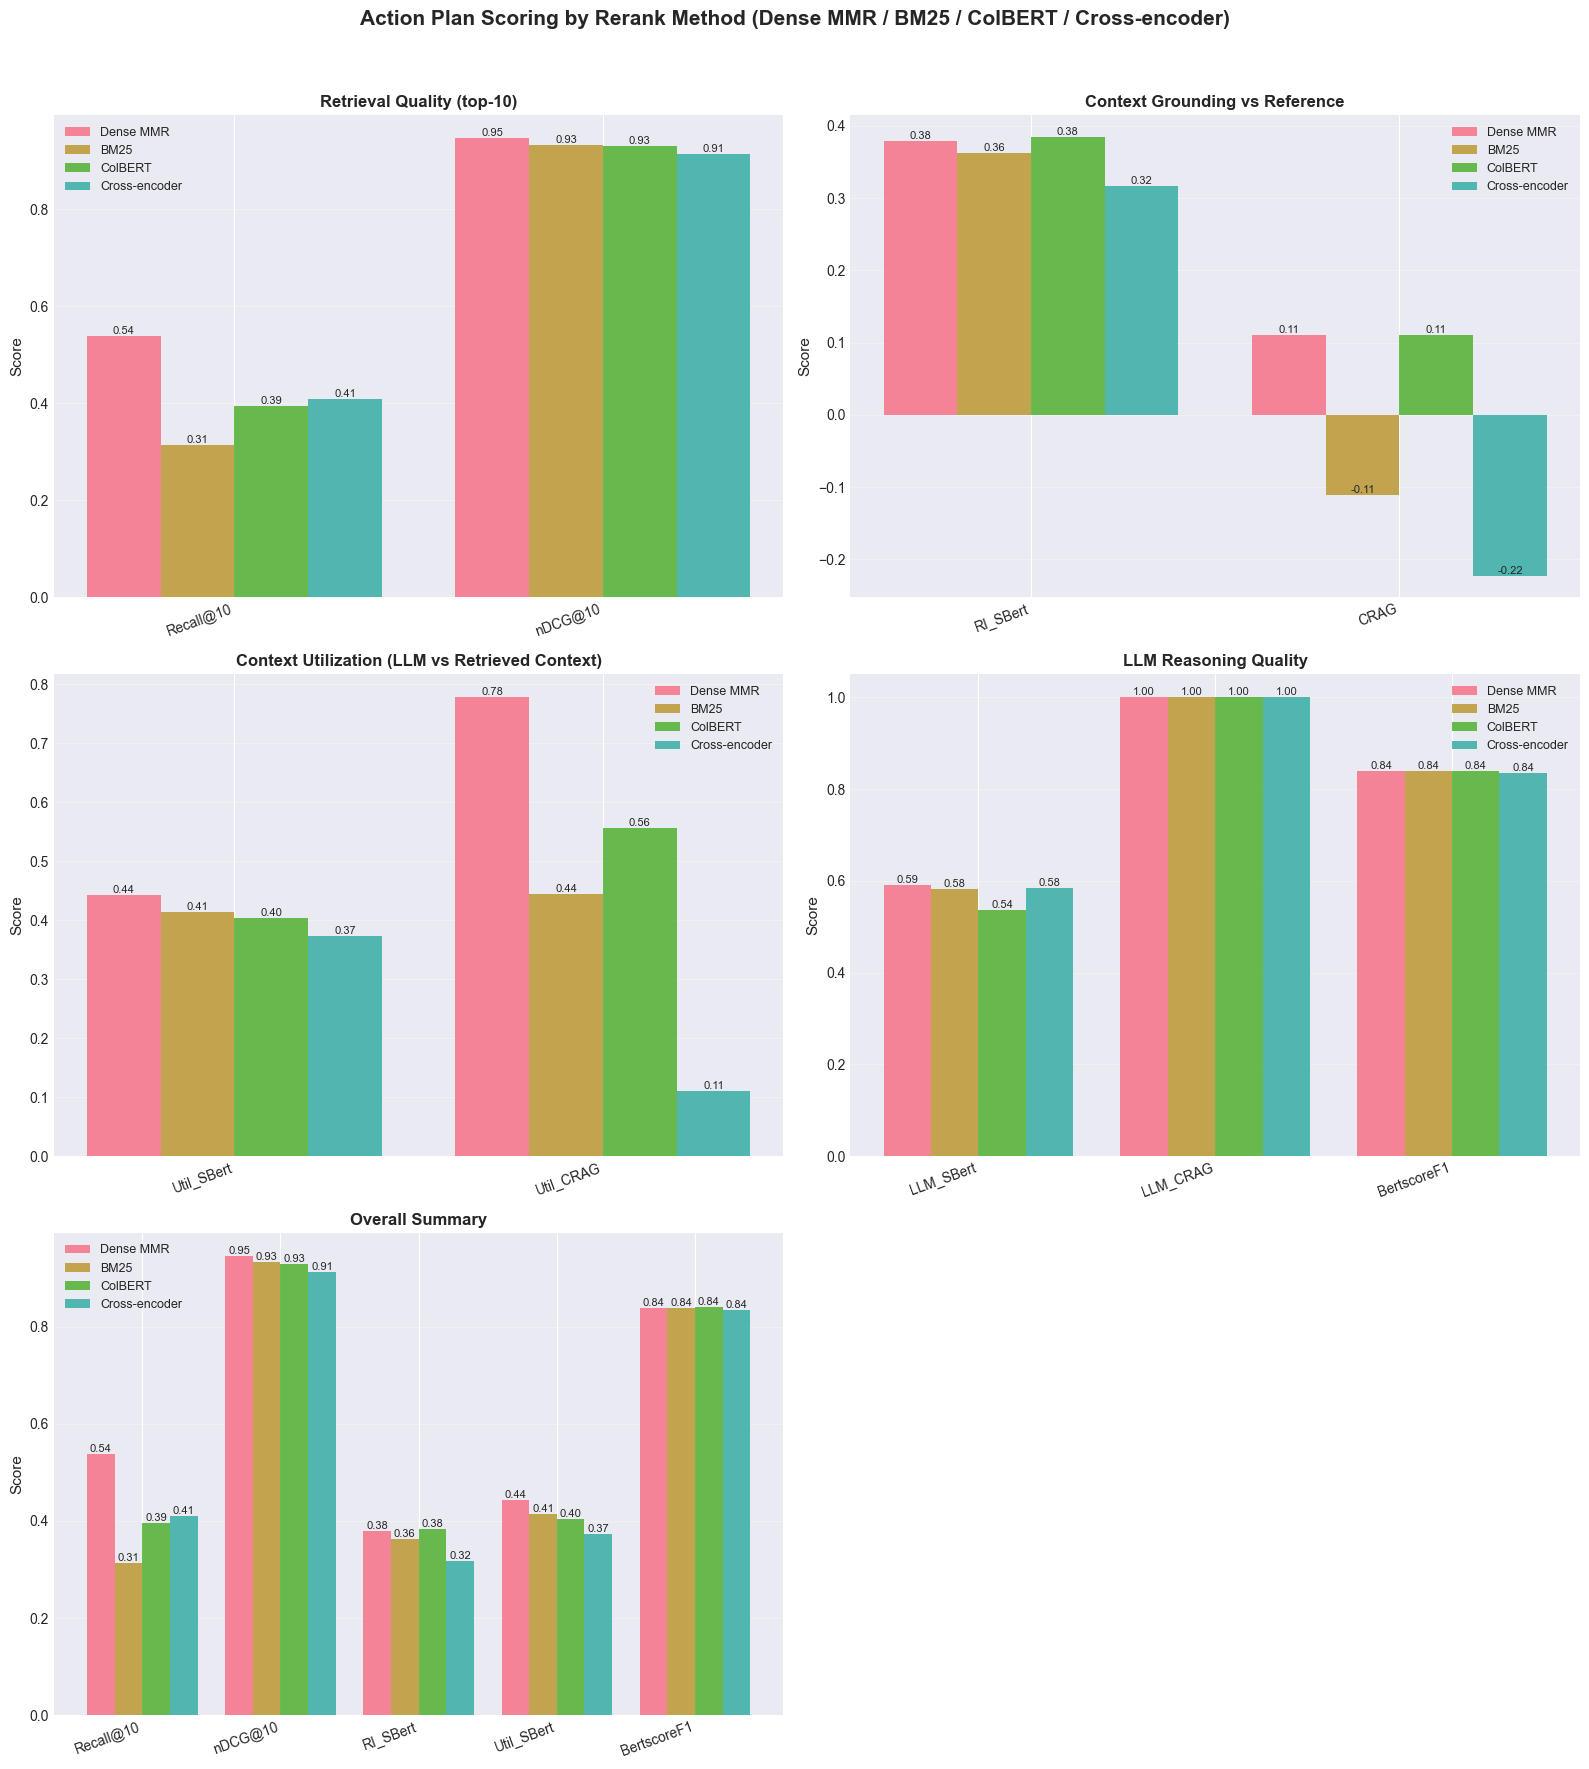


Visualizations created successfully!


In [44]:
# Set up plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except Exception:
    try:
        plt.style.use('seaborn-darkgrid')
    except Exception:
        plt.style.use('default')
sns.set_palette("husl")

# Visualizations: one bar per rerank method, grouped by metric
if not df_results.empty and len(df_results) > 0:
    method_display = {
        "none": "Dense MMR",
        "bm25": "BM25",
        "colbert": "ColBERT",
        "crossencoder": "Cross-encoder",
    }
    method_order = [m for m in ["none", "bm25", "colbert", "crossencoder"] if m in df_results["method"].unique()]

    if not method_order:
        print("No known rerank methods found in df_results['method'].")
    else:
        all_metrics = [
            "recall_at_10",
            "ndcg_at_10",
            "context_sbert_cosine",
            "context_crag_proxy",
            "utilization_sbert_cosine",
            "utilization_crag_proxy",
            "reasoning_sbert_cosine",
            "reasoning_crag_proxy",
            "bertscore_f1",
        ]
        avg_scores = (
            df_results.groupby("method")[all_metrics].mean().reindex(method_order)
        )

        def _grouped_bar(ax, metrics, metric_labels, title):
            x = np.arange(len(metrics))
            n_methods = len(method_order)
            width = 0.8 / max(n_methods, 1)
            for i, m in enumerate(method_order):
                values = [avg_scores.loc[m, metric] for metric in metrics]
                offset = (i - (n_methods - 1) / 2) * width
                bars = ax.bar(x + offset, values, width, label=method_display[m], alpha=0.85)
                for rect, v in zip(bars, values):
                    if np.isfinite(v):
                        ax.text(
                            rect.get_x() + rect.get_width() / 2,
                            rect.get_height(),
                            f"{v:.2f}",
                            ha="center",
                            va="bottom",
                            fontsize=8,
                        )
            ax.set_xticks(x)
            ax.set_xticklabels(metric_labels, rotation=20, ha="right")
            ax.set_ylabel("Score", fontsize=11)
            ax.set_title(title, fontsize=12, fontweight="bold")
            ax.legend(fontsize=9)
            ax.grid(axis="y", alpha=0.3)

        fig, axes = plt.subplots(3, 2, figsize=(16, 18))
        fig.suptitle(
            "Action Plan Scoring by Rerank Method (Dense MMR / BM25 / ColBERT / Cross-encoder)",
            fontsize=15,
            fontweight="bold",
        )

        _grouped_bar(
            axes[0, 0],
            ["recall_at_10", "ndcg_at_10"],
            ["Recall@10", "nDCG@10"],
            "Retrieval Quality (top-10)",
        )
        _grouped_bar(
            axes[0, 1],
            ["context_sbert_cosine", "context_crag_proxy"],
            ["RI_SBert", "CRAG"],
            "Context Grounding vs Reference",
        )
        _grouped_bar(
            axes[1, 0],
            ["utilization_sbert_cosine", "utilization_crag_proxy"],
            ["Util_SBert", "Util_CRAG"],
            "Context Utilization (LLM vs Retrieved Context)",
        )
        _grouped_bar(
            axes[1, 1],
            ["reasoning_sbert_cosine", "reasoning_crag_proxy", "bertscore_f1"],
            ["LLM_SBert", "LLM_CRAG", "BertscoreF1"],
            "LLM Reasoning Quality",
        )
        _grouped_bar(
            axes[2, 0],
            [
                "recall_at_10",
                "ndcg_at_10",
                "context_sbert_cosine",
                "utilization_sbert_cosine",
                "bertscore_f1",
            ],
            ["Recall@10", "nDCG@10", "RI_SBert", "Util_SBert", "BertscoreF1"],
            "Overall Summary",
        )
        axes[2, 1].set_visible(False)

        plt.tight_layout(rect=(0, 0, 1, 0.96))
        plt.show()

        print("\nVisualizations created successfully!")
else:
    print("No data available for visualization!")

In [45]:
# Display individual file scores
if not df_results.empty:
    print("\nIndividual File Scores:")
    print("=" * 100)

    for file_name in df_results["file_name"].unique():
        file_data = df_results[df_results["file_name"] == file_name]
        print(f"\nFile: {file_name}")
        print("-" * 100)

        for _, row in file_data.iterrows():
            print(f"\nMode: {str(row['method']).upper()}")
            print(f"  Recall@10:              {row['recall_at_10']:.4f}")
            print(f"  nDCG@10:                {row['ndcg_at_10']:.4f}")
            print(f"  Context SBERT Cosine:   {row['context_sbert_cosine']:.4f}")
            print(f"  Context CRAG Proxy:     {row['context_crag_proxy']:.4f}")
            print(f"  Utilization SBERT:      {row['utilization_sbert_cosine']:.4f}")
            print(f"  Utilization CRAG Proxy: {row['utilization_crag_proxy']:.4f}")
            print(f"  Reasoning SBERT Cosine: {row['reasoning_sbert_cosine']:.4f}")
            print(f"  Reasoning CRAG Proxy:   {row['reasoning_crag_proxy']:.4f}")
            print(f"  BERTScore-F1:           {row['bertscore_f1']:.4f}")
            reasoning_text = str(row.get("text", "") or "")
            print(
                f"  Overall Reasoning: {reasoning_text[:120]}..."
                if len(reasoning_text) > 120
                else f"  Overall Reasoning: {reasoning_text}"
            )
else:
    print("No results to display!")


Individual File Scores:

File: rerank_comparison_sample_0_20260421_141522_302176.json
----------------------------------------------------------------------------------------------------

Mode: NONE
  Recall@10:              0.5294
  nDCG@10:                0.9870
  Context SBERT Cosine:   0.4702
  Context CRAG Proxy:     1.0000
  Utilization SBERT:      0.4443
  Utilization CRAG Proxy: 1.0000
  Reasoning SBERT Cosine: 0.5256
  Reasoning CRAG Proxy:   1.0000
  BERTScore-F1:           0.8552
  Overall Reasoning: The RAN tier is prioritized for the primary action due to its dominant contribution to the benign classification, while ...

Mode: BM25
  Recall@10:              0.4706
  nDCG@10:                0.9444
  Context SBERT Cosine:   0.3566
  Context CRAG Proxy:     0.0000
  Utilization SBERT:      0.2945
  Utilization CRAG Proxy: -1.0000
  Reasoning SBERT Cosine: 0.5569
  Reasoning CRAG Proxy:   1.0000
  BERTScore-F1:           0.8579
  Overall Reasoning: The RAN tier is prioritized

## Save Results to JSON

Writes `RAG_docs/scoring/scoring_results.json` containing:

- `metric_notes` — prose summary of each metric and how thresholds are derived.
- `adaptive_thresholds_used` — the batch-level thresholds produced by `derive_adaptive_thresholds` for this run.
- `top_k`, `total_files`, `timestamp` — run-level metadata.
- `individual_scores` — the full per-row dictionaries (including `pool_size` and `relevance_threshold_used`).
- `average_scores` — per-rerank-mode averages over all verbose metric columns.

In [46]:
# Save detailed results to JSON
if scoring_results:
    scoring_dir = Path("RAG_docs/scoring")
    scoring_dir.mkdir(parents=True, exist_ok=True)

    output_file = scoring_dir / "scoring_results.json"

    output_data = {
        "metric_notes": {
            "retrieval": (
                "Recall@10 is computed over a wider candidate_pool (persisted by "
                "Plan.ipynb, typically 30 chunks per mode) using a weak graded "
                "relevance score = 0.5 * ROUGE-1 + 0.5 * SBERT vs. a label-derived "
                "reference string built from attack_options.json + "
                "agentic_features.json (actions grouped by capable agent)."
            ),
            "ndcg": "nDCG@10 uses the same graded relevance over the top-10 ranked chunks.",
            "context": (
                "SBERT cosine and CRAG-style proxy (+1/0/-1) between retrieved top-10 "
                "context and reference text. The CRAG proxy uses 3-valued adaptive "
                "thresholds (batch median / 25th percentile, clamped to relaxed floors)."
            ),
            "utilization": (
                "SBERT cosine and CRAG-style proxy (+1/0/-1) between retrieved top-10 "
                "context and overall_reasoning. Measures how much of the retrieved "
                "evidence the LLM actually used / grounded its answer in (faithfulness "
                "proxy). Uses the same adaptive CRAG thresholds as the context metric."
            ),
            "reasoning": "SBERT cosine + ROUGE-1 + CRAG-style proxy between overall_reasoning and reference text.",
            "bertscore": "BERTScore-F1 computed between ground-truth reference statement and overall_reasoning.",
        },
        "adaptive_thresholds_used": adaptive,
        "top_k": TOP_K,
        "total_files": len(comparison_data),
        "timestamp": pd.Timestamp.now().isoformat(),
        "individual_scores": scoring_results,
        "average_scores": {},
    }

    if not df_results.empty:
        metric_cols = [
            "recall_at_10",
            "ndcg_at_10",
            "context_sbert_cosine",
            "context_rouge1",
            "context_crag_proxy",
            "utilization_sbert_cosine",
            "utilization_rouge1",
            "utilization_crag_proxy",
            "reasoning_sbert_cosine",
            "reasoning_rouge1",
            "reasoning_crag_proxy",
            "bertscore_precision",
            "bertscore_recall",
            "bertscore_f1",
        ]
        for method in sorted(df_results["method"].unique()):
            method_data = df_results[df_results["method"] == method]
            output_data["average_scores"][method] = {
                metric: float(method_data[metric].mean()) for metric in metric_cols
            }

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(output_data, f, indent=2, ensure_ascii=False)

    print(f"Results saved to: {output_file}")
else:
    print("No results to save!")

Results saved to: RAG_docs\scoring\scoring_results.json


In [47]:
# Average metrics CSV (Dense MMR, BM25, ColBERT, Cross-encoder)
if not df_results.empty:
    _method_display = {
        "none": "Dense MMR",
        "bm25": "BM25",
        "colbert": "ColBERT",
        "crossencoder": "Cross-encoder",
    }
    _row_order = ["none", "bm25", "colbert", "crossencoder"]

    _agg = (
        df_results.groupby("method", as_index=False)
        .agg(
            recall_at_10=("recall_at_10", "mean"),
            ndcg_at_10=("ndcg_at_10", "mean"),
            ri_sbert=("context_sbert_cosine", "mean"),
            ri_crag=("context_crag_proxy", "mean"),
            util_sbert=("utilization_sbert_cosine", "mean"),
            util_crag=("utilization_crag_proxy", "mean"),
            llm_sbert=("reasoning_sbert_cosine", "mean"),
            llm_crag=("reasoning_crag_proxy", "mean"),
            bertscore_f1=("bertscore_f1", "mean"),
        )
    )

    rows_out = []
    for key in _row_order:
        sub = _agg[_agg["method"] == key]
        if sub.empty:
            continue
        r = sub.iloc[0]
        rows_out.append(
            {
                "Method": _method_display[key],
                "Recall@10": round(float(r["recall_at_10"]), 6),
                "nDCG@10": round(float(r["ndcg_at_10"]), 6),
                "RI_SBert": round(float(r["ri_sbert"]), 6),
                "CRAG": round(float(r["ri_crag"]), 6),
                "Util_SBert": round(float(r["util_sbert"]), 6),
                "Util_CRAG": round(float(r["util_crag"]), 6),
                "LLM_SBert": round(float(r["llm_sbert"]), 6),
                "LLM_CRAG": round(float(r["llm_crag"]), 6),
                "BertscoreF1": round(float(r["bertscore_f1"]), 6),
            }
        )

    summary_df = pd.DataFrame(rows_out)
    scoring_dir = Path("RAG_docs/scoring")
    scoring_dir.mkdir(parents=True, exist_ok=True)
    csv_path = scoring_dir / "rerank_method_averages.csv"
    summary_df.to_csv(csv_path, index=False)
    print(f"\nAverage-by-method CSV written to: {csv_path}")
    print(summary_df.to_string(index=False))
else:
    print("No results — skipping rerank_method_averages.csv")



Average-by-method CSV written to: RAG_docs\scoring\rerank_method_averages.csv
       Method  Recall@10  nDCG@10  RI_SBert      CRAG  Util_SBert  Util_CRAG  LLM_SBert  LLM_CRAG  BertscoreF1
    Dense MMR   0.538238 0.945656  0.379410  0.111111    0.442387   0.777778   0.591470       1.0     0.839642
         BM25   0.313689 0.932691  0.361906 -0.111111    0.414297   0.444444   0.582089       1.0     0.838663
      ColBERT   0.394847 0.929244  0.384127  0.111111    0.403604   0.555556   0.537369       1.0     0.840282
Cross-encoder   0.409436 0.912788  0.317231 -0.222222    0.373852   0.111111   0.584944       1.0     0.835645
